# EDA: graficos, pruebas estadisticas y regresion

Notebook de demostracion con el dataset **personality_synthetic_dataset** (rasgos de personalidad 0–10 y tipo: Introvert, Ambivert, Extrovert).

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from scripts import (
    GraficosCuantitativos,
    GraficosCualitativos,
    TestEstadisticos,
    RegresionLineal,
    RegresionLogistica,
)

sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)

# Variables numericas de interes para los graficos
VARS_NUM = [
    "social_energy", "talkativeness", "empathy",
    "creativity", "leadership", "party_liking",
]

In [ ]:
df = pd.read_csv("datos/personality_synthetic_dataset.csv")
df["personality_type"] = df["personality_type"].astype("category")
df["alta_energia"] = (df["social_energy"] > df["social_energy"].median()).map({True: "si", False: "no"})

# Muestra para graficos pesados (pairplot, muchos puntos)
df_plot = df.sample(n=800, random_state=42)

print(df.shape)
df["personality_type"].value_counts()

(20000, 31)


personality_type
Extrovert    6857
Ambivert     6573
Introvert    6570
Name: count, dtype: int64

## 1) Graficos cuantitativos

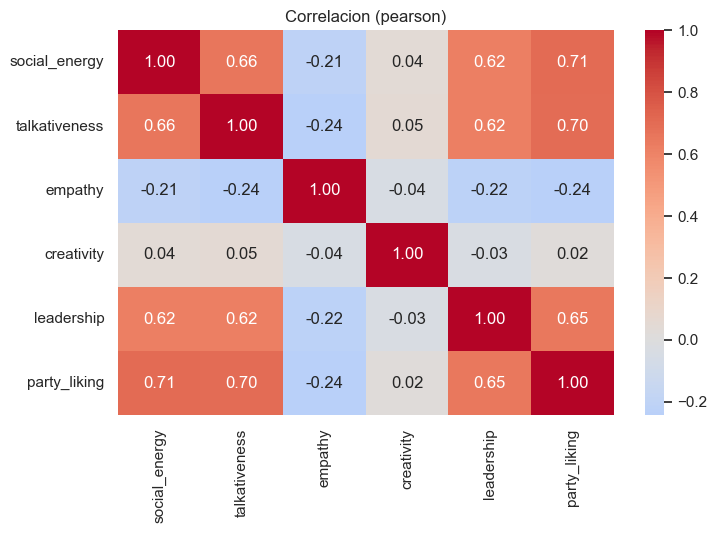

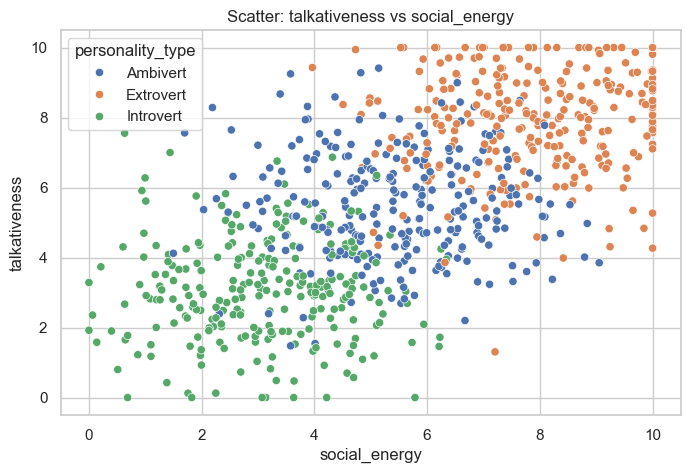

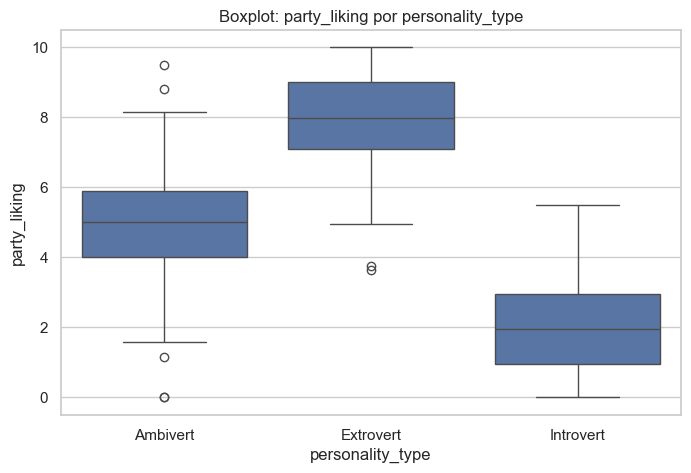

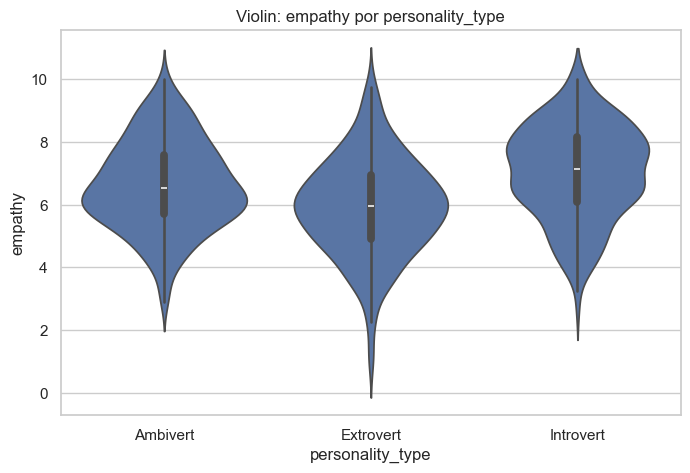

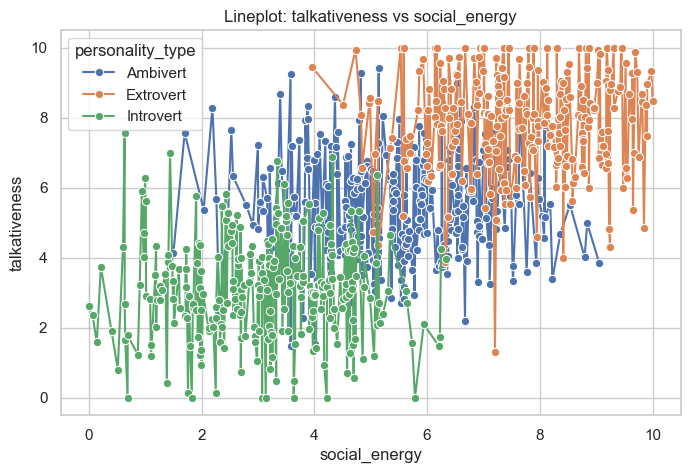

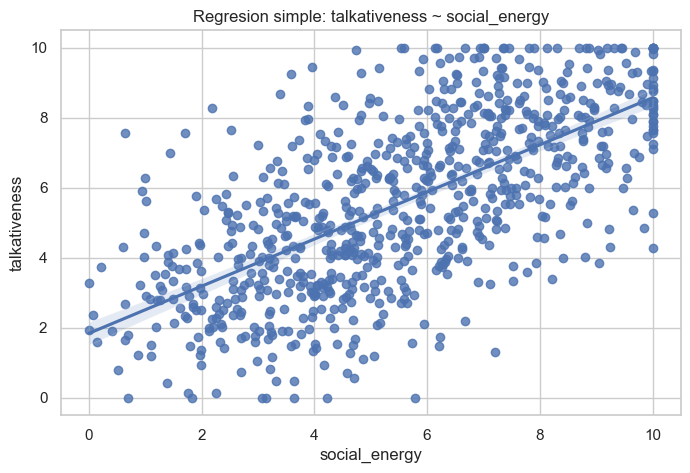

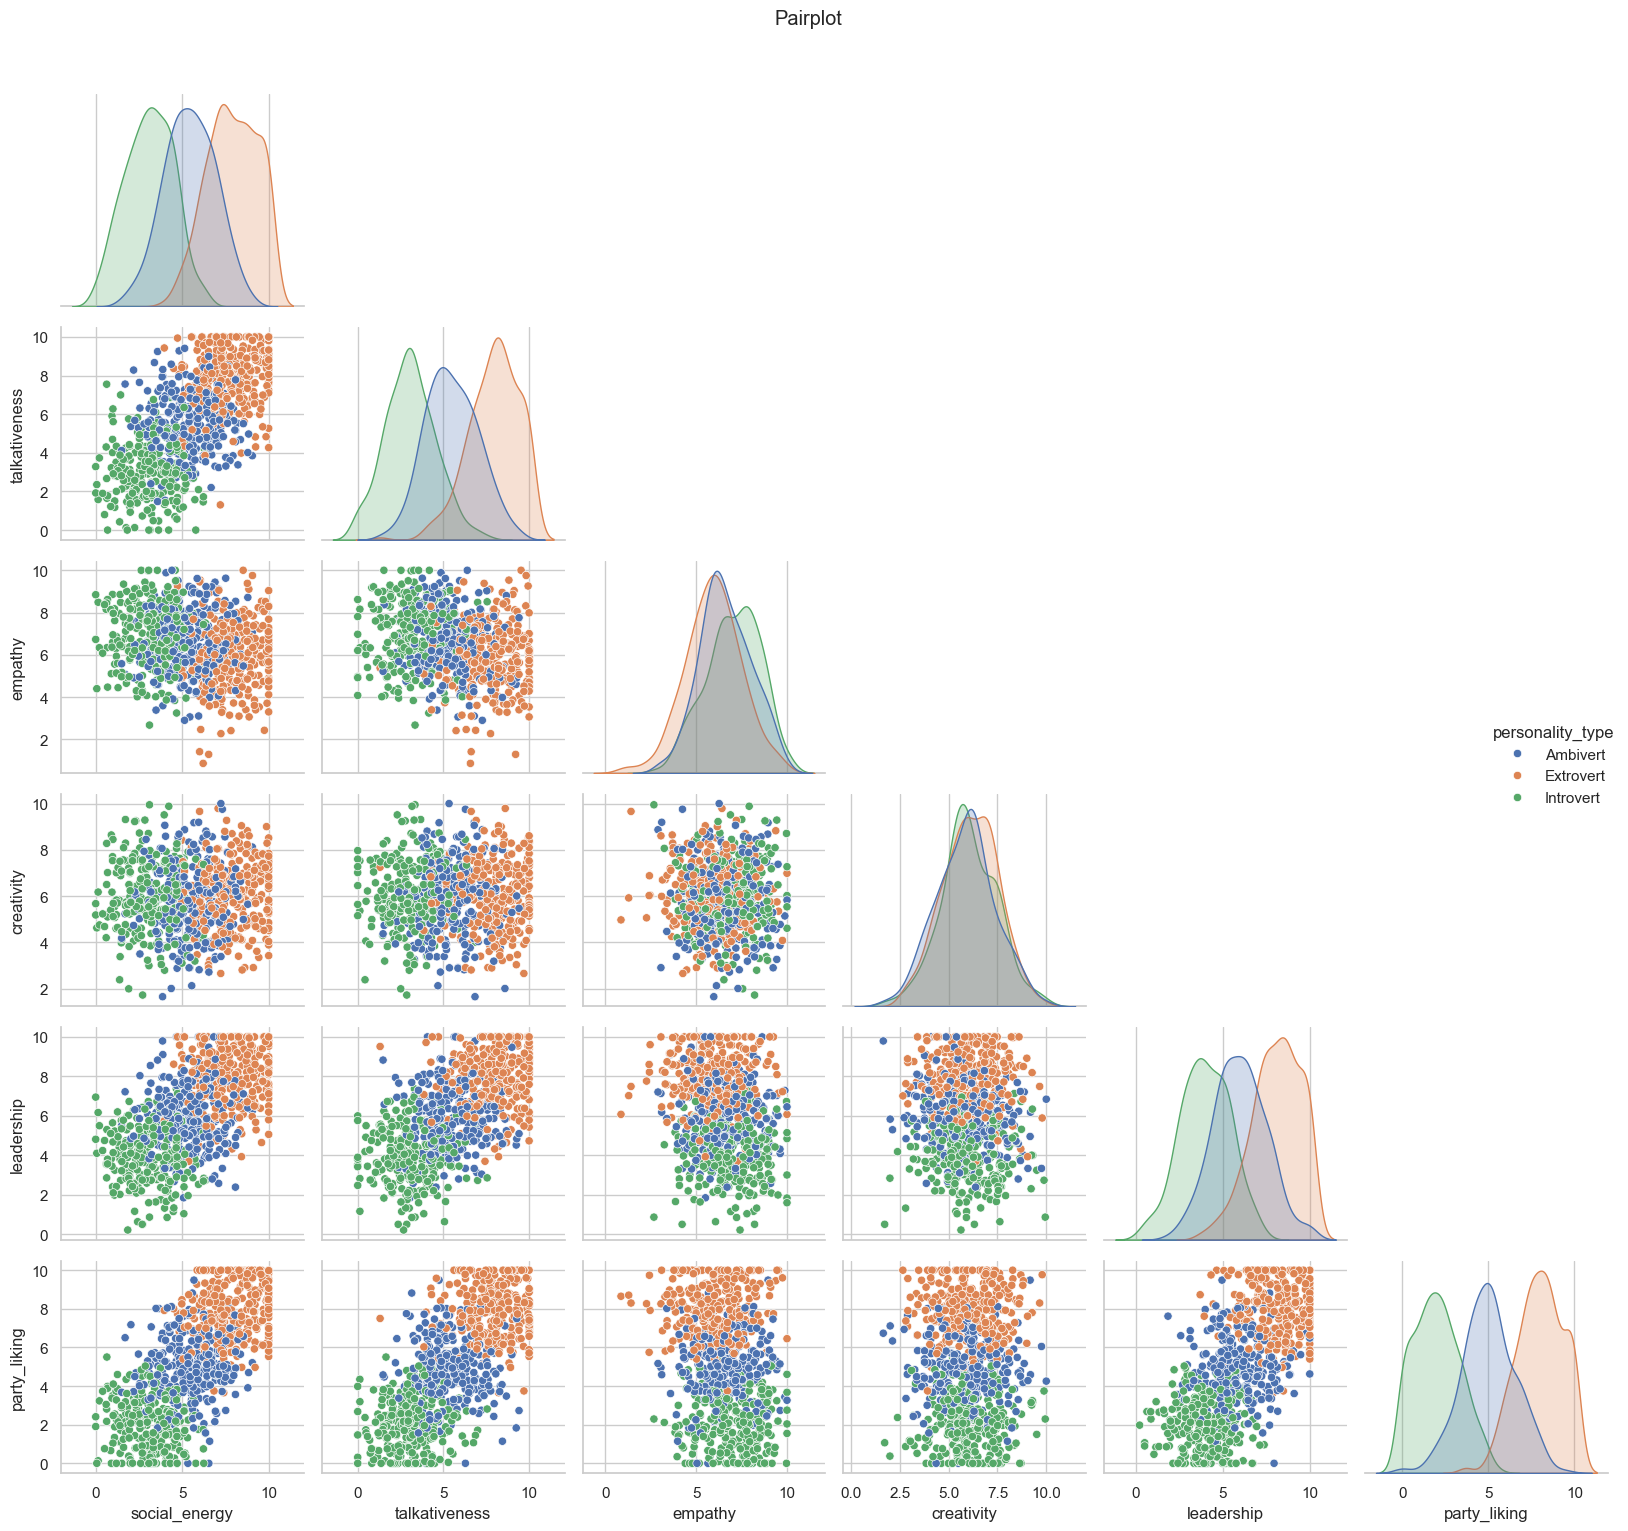

In [ ]:
g_cuant = GraficosCuantitativos(df_plot, cols=VARS_NUM)

g_cuant.heatmap_correlacion()
plt.show()

g_cuant.scatter("social_energy", "talkativeness", hue="personality_type")
plt.show()

g_cuant.boxplot(x="personality_type", y="party_liking")
plt.show()

g_cuant.violin(x="personality_type", y="empathy")
plt.show()

g_cuant.lineplot(x="social_energy", y="talkativeness", hue="personality_type")
plt.show()

g_cuant.regplot("social_energy", "talkativeness")
plt.show()

g_cuant.pairplot(hue="personality_type")
plt.show()

## 2) Graficos cualitativos

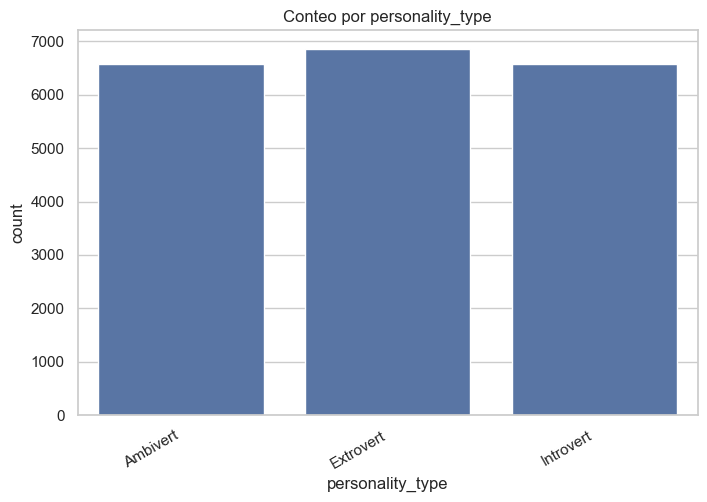

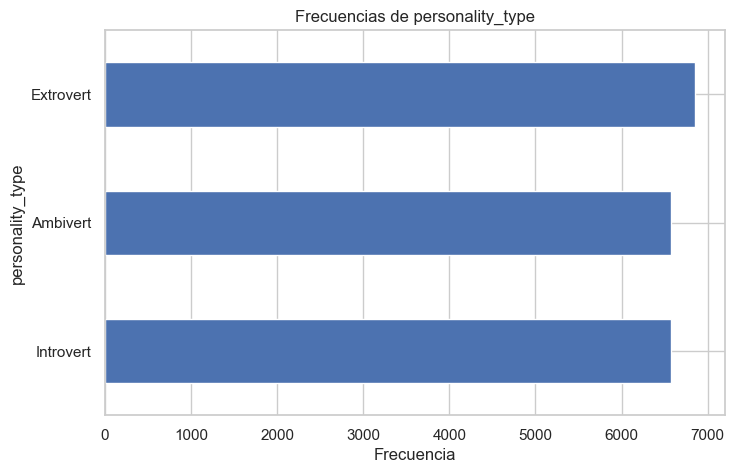

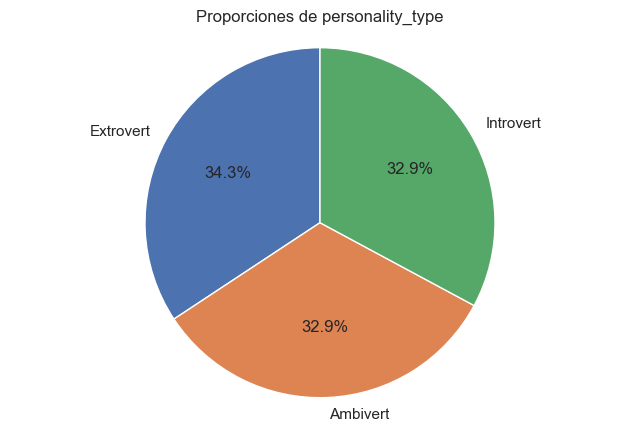

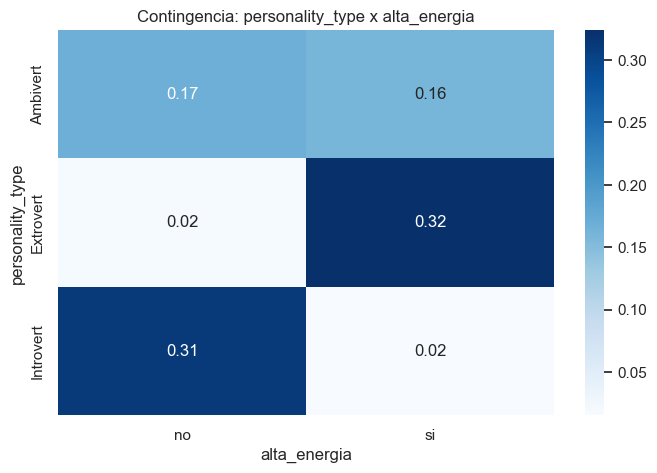

In [ ]:
g_cual = GraficosCualitativos(df, cols=["personality_type"])

g_cual.countplot("personality_type")
plt.show()

g_cual.bar_frecuencias("personality_type")
plt.show()

g_cual.pie("personality_type")
plt.show()

g_cual.heatmap_contingencia("personality_type", "alta_energia", normalizar=True)
plt.show()

## 3) Pruebas estadisticas

In [ ]:
tests = TestEstadisticos(df)

print("ANOVA (talkativeness por personality_type):")
display(tests.anova("talkativeness", "personality_type"))

print("\nMANOVA:")
display(tests.manova("social_energy + talkativeness ~ personality_type"))

print("\nt de Student (Extrovert vs Introvert):")
display(pd.Series(tests.ttest_student(
    "party_liking", "personality_type", "Extrovert", "Introvert"
)))

print("\nChi-cuadrado (personality_type vs alta_energia):")
chi = tests.chi_cuadrado("personality_type", "alta_energia")
display(pd.Series({k: v for k, v in chi.items() if k not in ("tabla_observada", "tabla_esperada")}))
display(chi["tabla_observada"])

ANOVA (talkativeness por personality_type):


,df,sum_sq,mean_sq,F,PR(>F)
C(personality_type),2.0,81760.539483,40880.269741,19446.844628,0.0
Residual,19997.0,42036.781270,2.102154,NaN,NaN



MANOVA:



t de Student (Extrovert vs Introvert):


prueba     t independiente (Welch)
grupo_a                  Extrovert
grupo_b                  Introvert
t                       248.813017
p_valor                        0.0
media_a                   7.961159
media_b                      2.048
dtype: object


Chi-cuadrado (personality_type vs alta_energia):


chi2       10838.477578
p_valor        0.000000
gl             2.000000
dtype: float64

alta_energia,no,si
personality_type,,
Ambivert,3365,3208
Extrovert,374,6483
Introvert,6261,309


## 4) Regresion lineal multiple

                            OLS Regression Results                            
Dep. Variable:          talkativeness   R-squared:                       0.660
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     9724.
Date:                Mon, 18 May 2026   Prob (F-statistic):               0.00
Time:                        14:01:23   Log-Likelihood:                -35806.
No. Observations:               20000   AIC:                         7.162e+04
Df Residuals:                   19995   BIC:                         7.166e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

,coef,error_std,t,p_valor,ic_inf,ic_sup
Intercept,5.434025,0.061935,87.737442,0.000000,5.312627,5.555423
C(personality_type)[T.Extrovert],2.437756,0.030422,80.132666,0.000000,2.378127,2.497385
C(personality_type)[T.Introvert],-2.481168,0.030785,-80.597350,0.000000,-2.541509,-2.420828
social_energy,0.004926,0.007033,0.700397,0.483688,-0.008860,0.018712
empathy,0.006798,0.006916,0.982931,0.325653,-0.006758,0.020353


R2                 0.660463
R2_ajustado        0.660395
AIC            71622.342503
BIC            71661.859940
RMSE               1.449901
dtype: float64

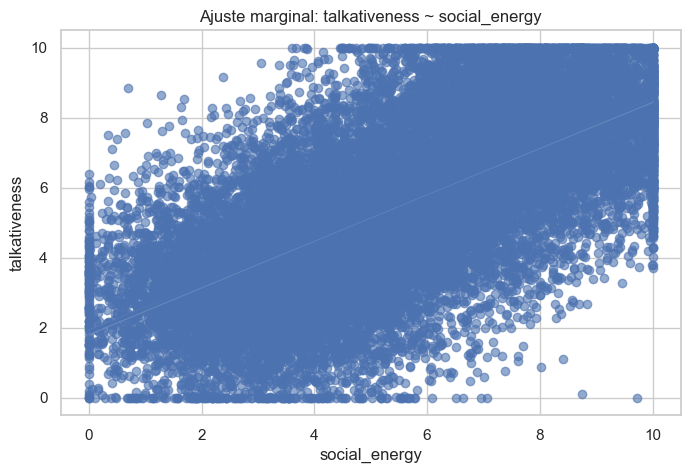

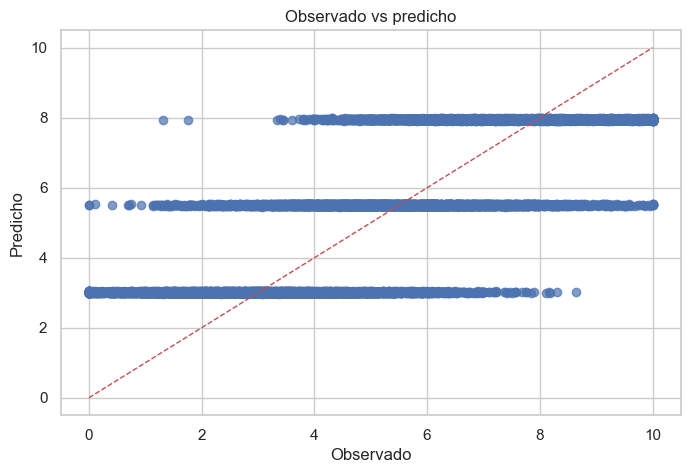

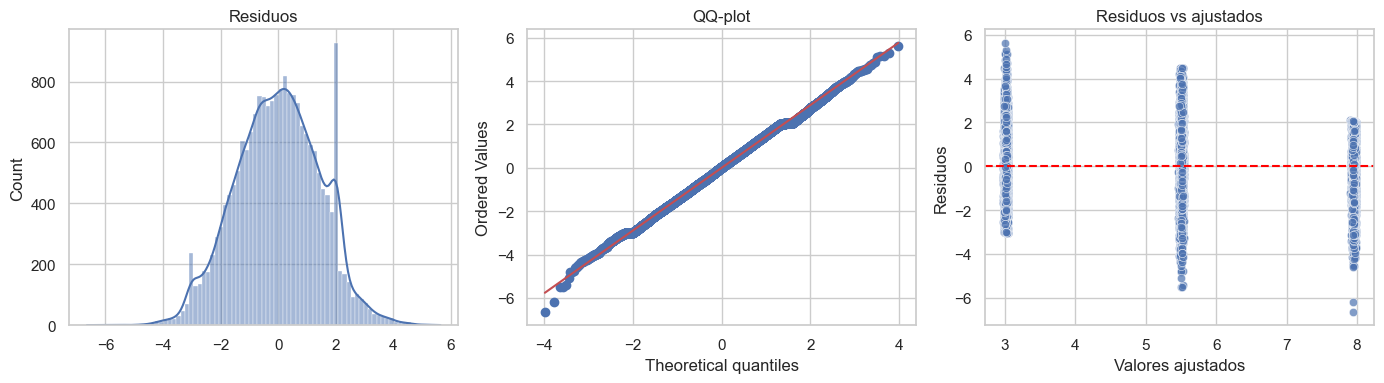

In [ ]:
reg_lin = RegresionLineal(
    "talkativeness ~ social_energy + empathy + C(personality_type)",
    df,
).ajustar()

print(reg_lin.resumen())
display(reg_lin.coeficientes())
display(reg_lin.bondad_ajuste())

reg_lin.grafico_regresion("social_energy", "talkativeness")
plt.show()

reg_lin.grafico_predichos_vs_observados()
plt.show()

reg_lin.diagnostico_residuos()
plt.show()

## 5) Regresion logistica

                           Logit Regression Results                           
Dep. Variable:           es_extrovert   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19996
Method:                           MLE   Df Model:                            3
Date:                Mon, 18 May 2026   Pseudo R-squ.:                  0.7576
Time:                        14:01:24   Log-Likelihood:                -3116.2
converged:                       True   LL-Null:                       -12858.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       -14.6187      0.307    -47.671      0.000     -15.220     -14.018
social_energy     1.0817      0.025     42.532      0.000       1.032       1.132
party_liking      1.3538      0.027     

,coef,error_std,z,p_valor,odds_ratio,ic_inf_or,ic_sup_or
Intercept,-14.618694,0.306658,-47.671041,0.000000e+00,4.479008e-07,2.455581e-07,8.169761e-07
social_energy,1.081704,0.025433,42.531588,0.000000e+00,2.949701e+00,2.806270e+00,3.100463e+00
party_liking,1.353809,0.027486,49.254786,0.000000e+00,3.872146e+00,3.669068e+00,4.086464e+00
empathy,-0.228028,0.022281,-10.234291,1.392107e-24,7.961020e-01,7.620847e-01,8.316376e-01


pseudo_R2            0.757649
AIC               6240.381032
BIC               6271.994982
log_likelihood   -3116.190516
dtype: float64

Predicho,0,1
Real,,
0.0,12501,642
1.0,647,6210


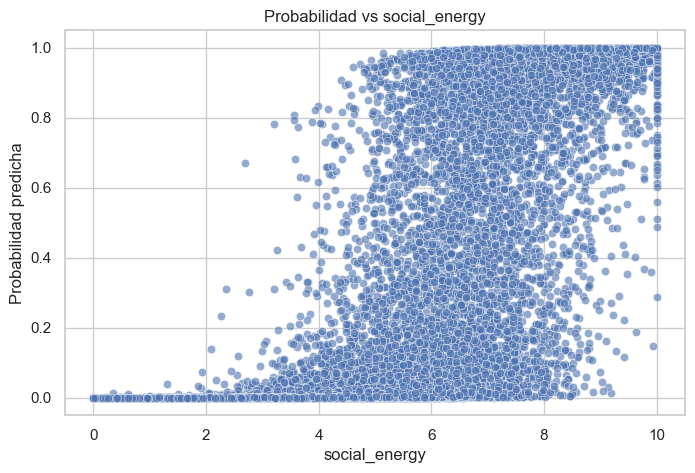

In [ ]:
df["es_extrovert"] = (df["personality_type"] == "Extrovert").astype(int)

reg_log = RegresionLogistica(
    "es_extrovert ~ social_energy + party_liking + empathy",
    df,
).ajustar()

print(reg_log.resumen())
display(reg_log.coeficientes())
display(reg_log.bondad_ajuste())
display(reg_log.matriz_confusion_basica())

reg_log.curva_roc_aprox("social_energy")
plt.show()